In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

PROJECT_DIR = Path(r"C:\Users\adaly\OneDrive\Documents\DMDeficientGalaxyTNG-1")
CATALOG = PROJECT_DIR / "data" / "dmdg_catalog_z0.csv"
df = pd.read_csv(CATALOG)

print(f"Total catalog objects: {len(df):,}")
resolved = df[
    (df["N_star"] >= 500) &
    (df["SubhaloFlag"] == 1) &
    (df["f_DM"].notna())
].copy()

print(f"Resolved galaxies: {len(resolved):,}")
centrals = resolved[
    resolved["IsSatellite"] == False
].copy()
dmdgs = centrals[
    centrals["f_DM"] < 0.5
].copy()
dmdgs_non_extreme = dmdgs[
   dmdgs["f_DM"] > 0.05
].copy()
print(f"Centrals: {len(centrals):,}")
print(f"DMDGS (total): {len(dmdgs):,}")
print(f"DMDGS (non-tidal stripping): {len(dmdgs_non_extreme):,}")
print(f"DMDGS Fraction: {(len(dmdgs_non_extreme) / len(centrals)):,}")


Total catalog objects: 13,922,457
Resolved galaxies: 154,638
Centrals: 93,039
DMDGS (total): 96
DMDGS (non-tidal stripping): 96
DMDGS Fraction: 0.0010318253635572179


In [5]:
import numpy as np
import pandas as pd
satellites = resolved[
    (resolved["IsSatellite"] == True) &
    resolved[["x", "y", "z"]].notna().all(axis=1)
].copy()

nearest_distances = []

for _, central in centrals.iterrows():

    sats = satellites[
        satellites["GroupID"] == central["GroupID"]
    ]

    if len(sats) == 0:
        nearest_distances.append(np.nan)
        continue

    box_size = 205000.0  # TNG300-1 box size in ckpc/h

    dx = np.abs(sats["x"].to_numpy() - central["x"])
    dy = np.abs(sats["y"].to_numpy() - central["y"])
    dz = np.abs(sats["z"].to_numpy() - central["z"])

    dx = np.minimum(dx, box_size - dx)
    dy = np.minimum(dy, box_size - dy)
    dz = np.minimum(dz, box_size - dz)

    distances = np.sqrt(dx**2 + dy**2 + dz**2)


    nearest_distances.append(np.min(distances))

centrals["NearestSatelliteDistance"] = nearest_distances

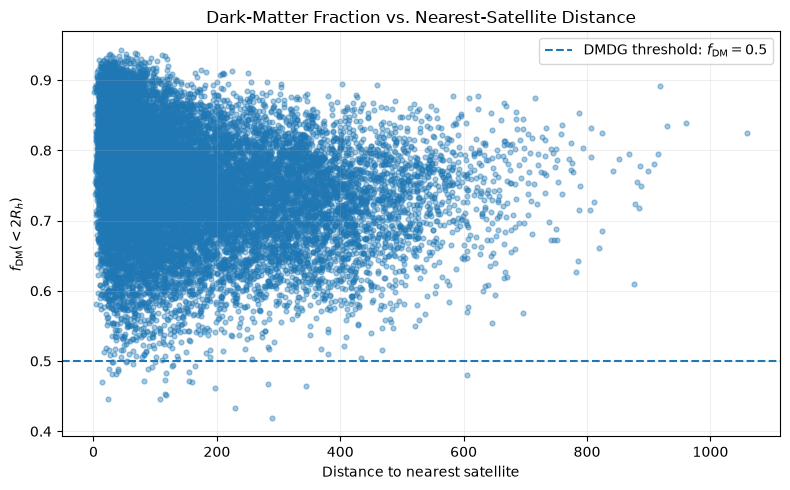

In [8]:
import matplotlib.pyplot as plt

plot_data = centrals.dropna(
    subset=["NearestSatelliteDistance", "f_DM"]
).copy()

plt.figure(figsize=(8, 5))

plt.scatter(
    plot_data["NearestSatelliteDistance"],
    plot_data["f_DM"],
    s=12,
    alpha=0.4
)

# DMDG threshold
plt.axhline(
    0.5,
    linestyle="--",
    linewidth=1.5,
    label=r"DMDG threshold: $f_{\rm DM}=0.5$"
)

plt.xlabel("Distance to nearest satellite")
plt.ylabel(r"$f_{\rm DM}(<2R_h)$")
plt.title("Dark-Matter Fraction vs. Nearest-Satellite Distance")

plt.grid(alpha=0.2)
plt.legend()

plt.tight_layout()
plt.show()

In [13]:
data = centrals[
    ["NearestSatelliteDistance", "f_DM"]
].dropna()

matrix = np.corrcoef(
    data["NearestSatelliteDistance"],
    data["f_DM"]
)

corr_coefficient = matrix[0, 1]

print(corr_coefficient)
dataDMDG = data[
   data["f_DM"] < 0.5
].copy()
matrix = np.corrcoef(
    dataDMDG["NearestSatelliteDistance"],
    dataDMDG["f_DM"]
)
corr_coefficient = matrix[0, 1]
print(corr_coefficient)

-0.1636380488973719
-0.33291448181775213
